In [ ]:
import os

if not os.path.exists("explainable-customer-churn-ml"):
    !git clone https://github.com/Chaitanyaprabhu08/explainable-customer-churn-ml.git

In [ ]:
!ls -lah explainable-customer-churn-ml/data

total 956K
drwxr-xr-x 2 root root 4.0K Sep  7 19:35 .
drwxr-xr-x 4 root root 4.0K Sep  7 19:35 ..
-rw-r--r-- 1 root root 948K Sep  7 19:35 WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
!ls explainable-customer-churn-ml

data  README.md  requirements.txt


In [ ]:
import pandas as pd

file_path = "explainable-customer-churn-ml/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
print("Number of rows and columns:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

Number of rows and columns: (7043, 21)

Columns:
1 - customerID
2 - gender
3 - SeniorCitizen
4 - Partner
5 - Dependents
6 - tenure
7 - PhoneService
8 - MultipleLines
9 - InternetService
10 - OnlineSecurity
11 - OnlineBackup
12 - DeviceProtection
13 - TechSupport
14 - StreamingTV
15 - StreamingMovies
16 - Contract
17 - PaperlessBilling
18 - PaymentMethod
19 - MonthlyCharges
20 - TotalCharges
21 - Churn


In [ ]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print("\nDuplicate rows:", df.duplicated().sum())

print("Duplicate customer IDs:", df["customerID"].duplicated().sum())


Duplicate rows: 0
Duplicate customer IDs: 0


In [ ]:
print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

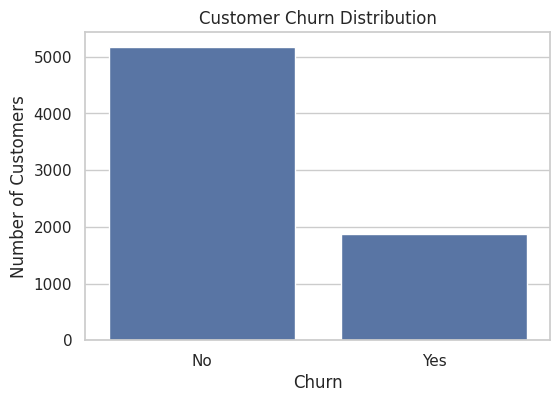

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

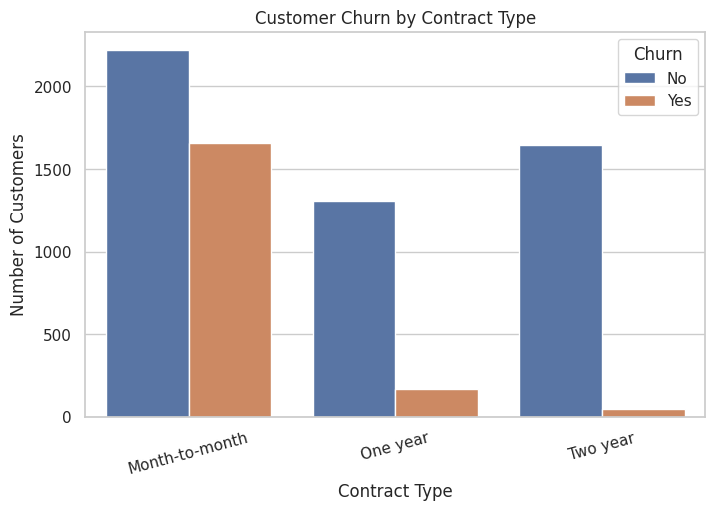

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

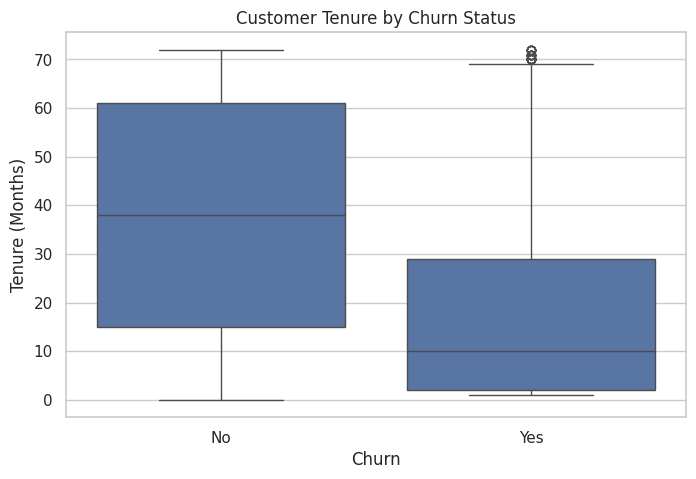

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

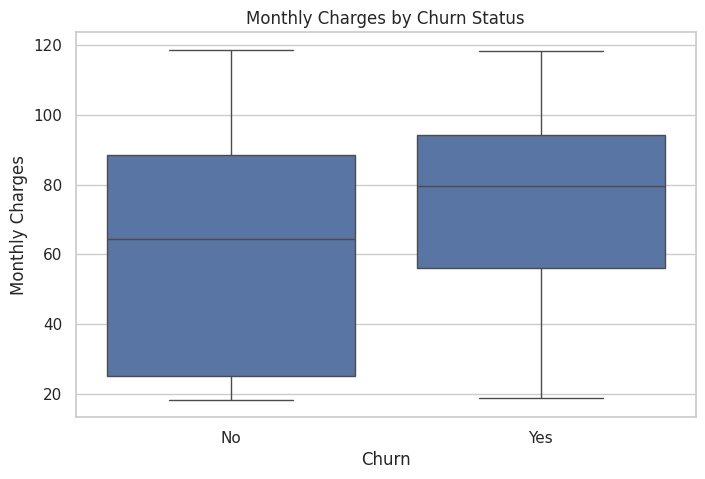

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

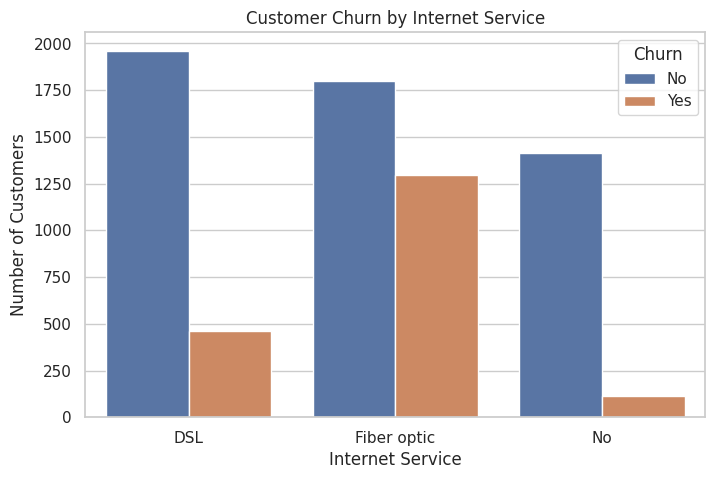

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

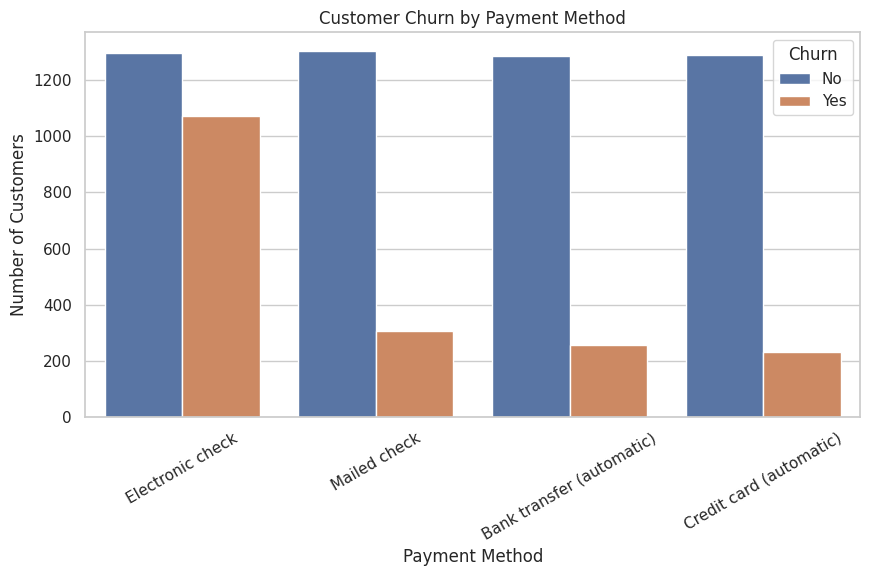

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [ ]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working copy shape:", df_clean.shape)

Original shape: (7043, 21)
Working copy shape: (7043, 21)


In [ ]:
df_clean = df_clean.drop(columns=["customerID"])

print("Shape after removing customerID:", df_clean.shape)

Shape after removing customerID: (7043, 20)


In [ ]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

print(df_clean["TotalCharges"].dtype)
print("Missing TotalCharges:", df_clean["TotalCharges"].isnull().sum())

float64
Missing TotalCharges: 11


In [ ]:
missing = df_clean.isnull().sum()

print(missing[missing > 0])

TotalCharges    11
dtype: int64


In [ ]:
df_clean[df_clean["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [ ]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

print("Missing TotalCharges after cleaning:",
      df_clean["TotalCharges"].isnull().sum())

Missing TotalCharges after cleaning: 0


In [ ]:
print("Shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum().sum())

print("\nData types:")
print(df_clean.dtypes)

Shape: (7043, 20)

Missing values:
0

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [ ]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
y = y.map({"No": 0, "Yes": 1})

print(y.value_counts())
print("\nUnique values:", y.unique())

Churn
0    5174
1    1869
Name: count, dtype: int64

Unique values: [0 1]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training features: (5634, 19)
Testing features: (1409, 19)

Training target distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [ ]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5634, 30)
Processed testing shape: (1409, 30)


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred_lr = logistic_model.predict(X_test_processed)

y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions:", y_pred_lr[:10])
print("Churn probabilities:", y_prob_lr[:10])

Predictions: [0 1 0 0 0 1 0 0 0 0]
Churn probabilities: [0.04624618 0.68221117 0.06297221 0.390808   0.02044554 0.60085858
 0.44185045 0.12597622 0.00269474 0.39426608]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.8041
Precision: 0.6541
Recall   : 0.5561
F1-score : 0.6012
ROC-AUC  : 0.8427


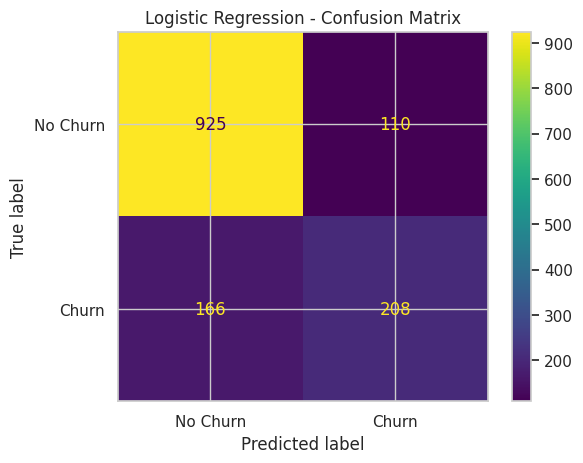

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully!")


Random Forest trained successfully!


In [ ]:
y_pred_rf = rf_model.predict(X_test_processed)

y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Results
---------------------
Accuracy : 0.7885
Precision: 0.6310
Recall   : 0.4893
F1-score : 0.5512
ROC-AUC  : 0.8273


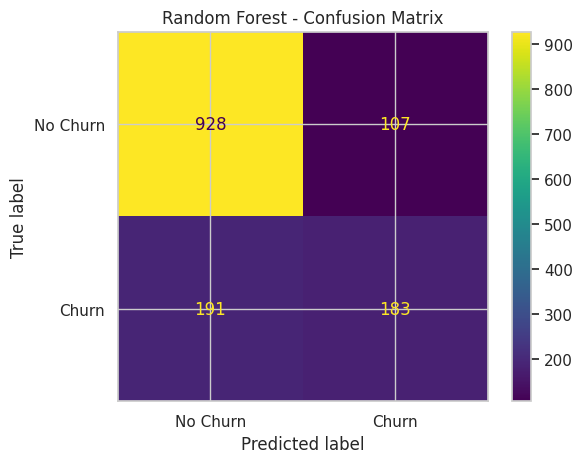

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
!pip install -q xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [ ]:
y_pred_xgb = xgb_model.predict(X_test_processed)

y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")

XGBoost Results
----------------
Accuracy : 0.8020
Precision: 0.6610
Recall   : 0.5214
F1-score : 0.5830
ROC-AUC  : 0.8418


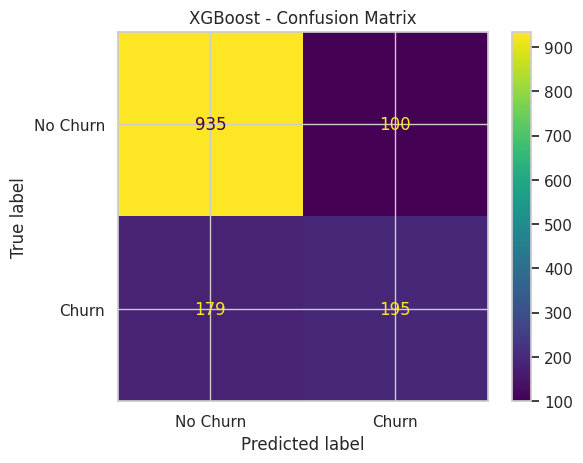

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_lr,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_lr,
        recall_rf,
        recall_xgb
    ],
    "F1-Score": [
        f1_lr,
        f1_rf,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.804116,0.654088,0.556150,0.601156,0.842652
1,Random Forest,0.788502,0.631034,0.489305,0.551205,0.827257
2,XGBoost,0.801987,0.661017,0.521390,0.582960,0.841777


In [ ]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8041,0.6541,0.5561,0.6012,0.8427
1,Random Forest,0.7885,0.6310,0.4893,0.5512,0.8273
2,XGBoost,0.8020,0.6610,0.5214,0.5830,0.8418


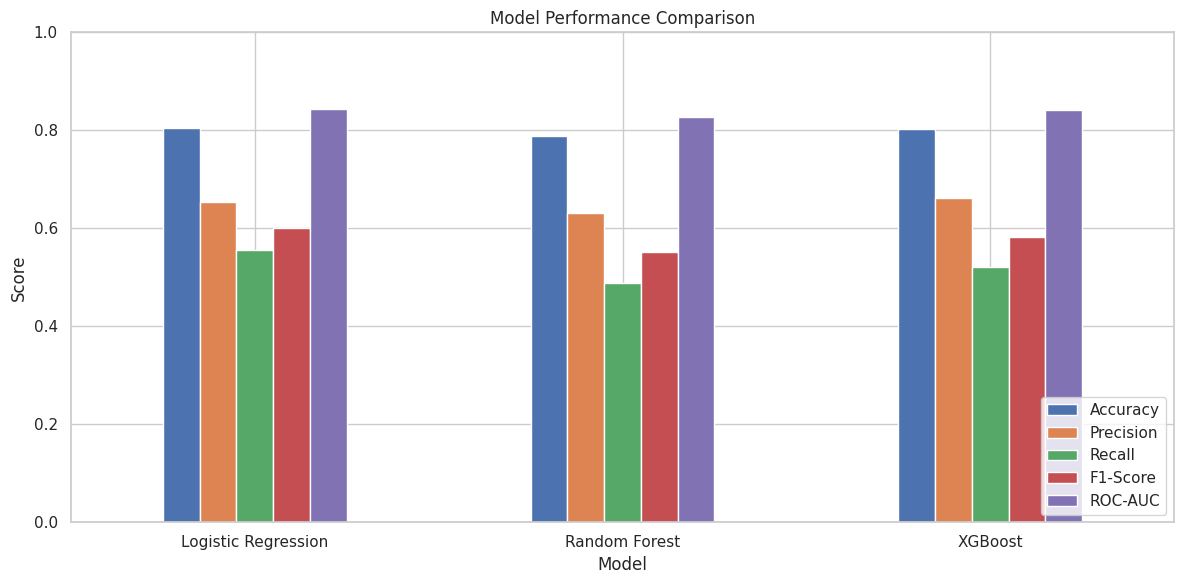

In [ ]:
results_plot = results.set_index("Model")

results_plot[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [ ]:
logistic_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_smote.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE Logistic Regression trained successfully!")

SMOTE Logistic Regression trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred_smote = logistic_smote.predict(X_test_processed)

y_prob_smote = logistic_smote.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)

print("SMOTE Logistic Regression Results")
print("----------------------------------")
print(f"Accuracy : {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall   : {recall_smote:.4f}")
print(f"F1-score : {f1_smote:.4f}")
print(f"ROC-AUC  : {roc_auc_smote:.4f}")

SMOTE Logistic Regression Results
----------------------------------
Accuracy : 0.7367
Precision: 0.5026
Recall   : 0.7861
F1-score : 0.6131
ROC-AUC  : 0.8398


In [ ]:
results_with_smote = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Logistic Regression + SMOTE"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_xgb,
        accuracy_smote
    ],
    "Precision": [
        precision_lr,
        precision_rf,
        precision_xgb,
        precision_smote
    ],
    "Recall": [
        recall_lr,
        recall_rf,
        recall_xgb,
        recall_smote
    ],
    "F1-Score": [
        f1_lr,
        f1_rf,
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_smote)
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_smote
    ]
})

results_with_smote.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8041,0.6541,0.5561,0.6012,0.8427
1,Random Forest,0.7885,0.6310,0.4893,0.5512,0.8273
2,XGBoost,0.8020,0.6610,0.5214,0.5830,0.8418
3,Logistic Regression + SMOTE,0.7367,0.5026,0.7861,0.6131,0.8398


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

lr_tuning = GridSearchCV(
    LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

lr_tuning.fit(
    X_train_smote,
    y_train_smote
)

print("Best parameters:", lr_tuning.best_params_)
print("Best cross-validation F1:", lr_tuning.best_score_)

Best parameters: {'C': 1}
Best cross-validation F1: 0.7787541509449432


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
best_lr = lr_tuning.best_estimator_

y_pred_tuned = best_lr.predict(X_test_processed)
y_prob_tuned = best_lr.predict_proba(X_test_processed)[:, 1]

print("Tuned Logistic Regression + SMOTE")
print("---------------------------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")

Tuned Logistic Regression + SMOTE
---------------------------------
Accuracy : 0.7331
Precision: 0.4983
Recall   : 0.7807
F1-score : 0.6083
ROC-AUC  : 0.8392


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed feature names:")
print(feature_names)

Number of processed features: 30

Processed feature names:
['categorical__gender_Male' 'categorical__Partner_Yes'
 'categorical__Dependents_Yes' 'categorical__PhoneService_Yes'
 'categorical__MultipleLines_No phone service'
 'categorical__MultipleLines_Yes'
 'categorical__InternetService_Fiber optic'
 'categorical__InternetService_No'
 'categorical__OnlineSecurity_No internet service'
 'categorical__OnlineSecurity_Yes'
 'categorical__OnlineBackup_No internet service'
 'categorical__OnlineBackup_Yes'
 'categorical__DeviceProtection_No internet service'
 'categorical__DeviceProtection_Yes'
 'categorical__TechSupport_No internet service'
 'categorical__TechSupport_Yes'
 'categorical__StreamingTV_No internet service'
 'categorical__StreamingTV_Yes'
 'categorical__StreamingMovies_No internet service'
 'categorical__StreamingMovies_Yes' 'categorical__Contract_One year'
 'categorical__Contract_Two year' 'categorical__PaperlessBilling_Yes'
 'categorical__PaymentMethod_Credit card (automatic)'


In [ ]:
!pip install -q shap

In [ ]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
explainer = shap.LinearExplainer(
    logistic_smote,
    X_train_smote
)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [ ]:
shap_values = explainer(X_test_processed)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


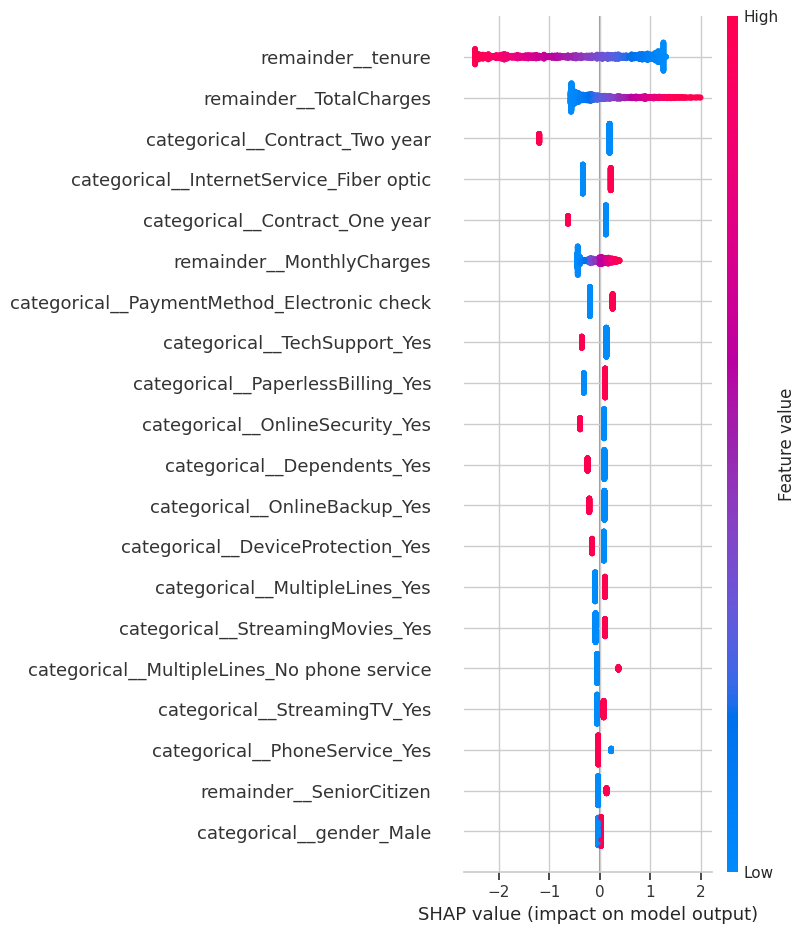

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

In [ ]:
# Find the test customer with the highest predicted churn probability
high_risk_idx = y_prob_smote.argmax()

print("Test customer position:", high_risk_idx)
print("Predicted churn probability:",
      f"{y_prob_smote[high_risk_idx] * 100:.2f}%")
print("Actual churn:",
      "Yes" if y_test.iloc[high_risk_idx] == 1 else "No")

Test customer position: 1090
Predicted churn probability: 94.66%
Actual churn: Yes


In [ ]:
customer_data = X_test.iloc[high_risk_idx]

print(customer_data)

gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  95.1
TotalCharges                    95.1
Name: 3380, dtype: object


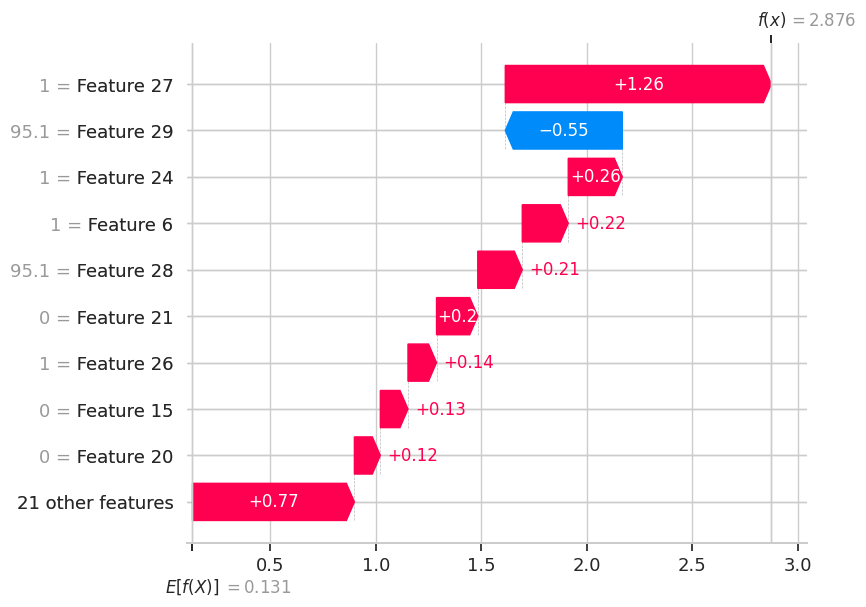

In [ ]:
customer_shap = shap_values[high_risk_idx]

shap.plots.waterfall(customer_shap, max_display=10)

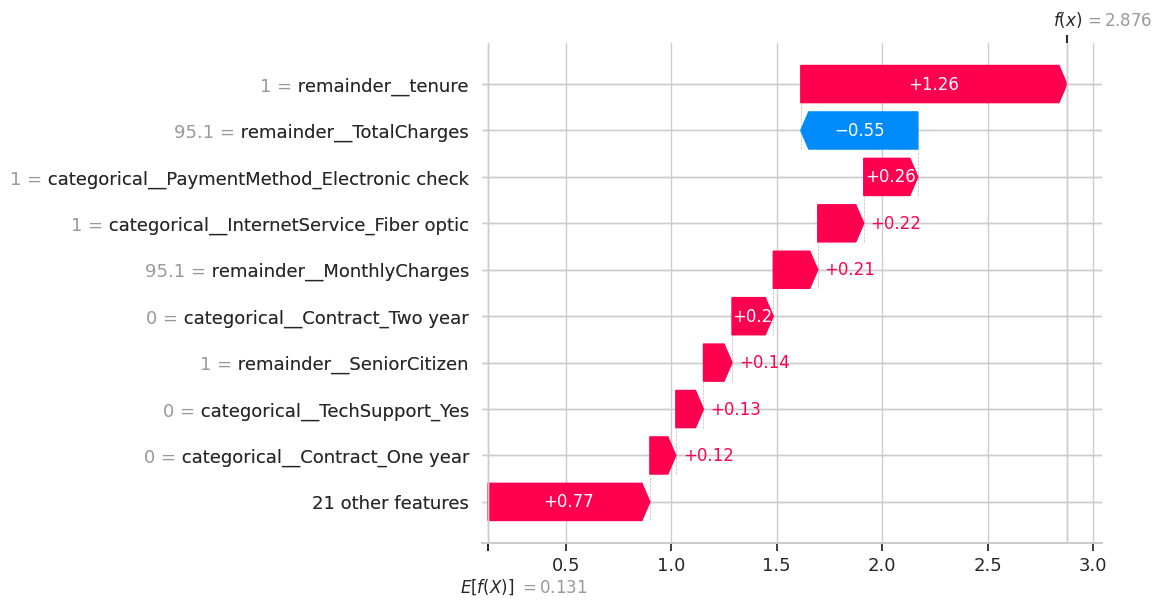

In [ ]:
# Convert the selected customer's processed data to a dense array
customer_data_processed = X_test_processed[high_risk_idx]

if hasattr(customer_data_processed, "toarray"):
    customer_data_processed = customer_data_processed.toarray().flatten()
else:
    customer_data_processed = customer_data_processed.flatten()

# Create a SHAP Explanation with the actual feature names
customer_explanation = shap.Explanation(
    values=shap_values[high_risk_idx].values,
    base_values=shap_values[high_risk_idx].base_values,
    data=customer_data_processed,
    feature_names=feature_names
)

# Display the explanation
shap.plots.waterfall(
    customer_explanation,
    max_display=10
)

In [ ]:
print("Individual Customer Explanation")
print("--------------------------------")
print(f"Predicted churn probability: {y_prob_smote[high_risk_idx] * 100:.2f}%")
print(
    "Predicted class:",
    "Churn" if y_pred_smote[high_risk_idx] == 1 else "No Churn"
)
print(
    "Actual class:",
    "Churn" if y_test.iloc[high_risk_idx] == 1 else "No Churn"
)

Individual Customer Explanation
--------------------------------
Predicted churn probability: 94.66%
Predicted class: Churn
Actual class: Churn


In [ ]:
clean_feature_names = []

for name in feature_names:
    name = name.replace("categorical__", "")
    name = name.replace("remainder__", "")
    name = name.replace("_", " ")
    clean_feature_names.append(name)

print(clean_feature_names)

['gender Male', 'Partner Yes', 'Dependents Yes', 'PhoneService Yes', 'MultipleLines No phone service', 'MultipleLines Yes', 'InternetService Fiber optic', 'InternetService No', 'OnlineSecurity No internet service', 'OnlineSecurity Yes', 'OnlineBackup No internet service', 'OnlineBackup Yes', 'DeviceProtection No internet service', 'DeviceProtection Yes', 'TechSupport No internet service', 'TechSupport Yes', 'StreamingTV No internet service', 'StreamingTV Yes', 'StreamingMovies No internet service', 'StreamingMovies Yes', 'Contract One year', 'Contract Two year', 'PaperlessBilling Yes', 'PaymentMethod Credit card (automatic)', 'PaymentMethod Electronic check', 'PaymentMethod Mailed check', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
clean_feature_names = []

for name in feature_names:
    name = name.replace("categorical__", "")
    name = name.replace("remainder__", "")
    name = name.replace("_", " ")
    clean_feature_names.append(name)

print(clean_feature_names)

['gender Male', 'Partner Yes', 'Dependents Yes', 'PhoneService Yes', 'MultipleLines No phone service', 'MultipleLines Yes', 'InternetService Fiber optic', 'InternetService No', 'OnlineSecurity No internet service', 'OnlineSecurity Yes', 'OnlineBackup No internet service', 'OnlineBackup Yes', 'DeviceProtection No internet service', 'DeviceProtection Yes', 'TechSupport No internet service', 'TechSupport Yes', 'StreamingTV No internet service', 'StreamingTV Yes', 'StreamingMovies No internet service', 'StreamingMovies Yes', 'Contract One year', 'Contract Two year', 'PaperlessBilling Yes', 'PaymentMethod Credit card (automatic)', 'PaymentMethod Electronic check', 'PaymentMethod Mailed check', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


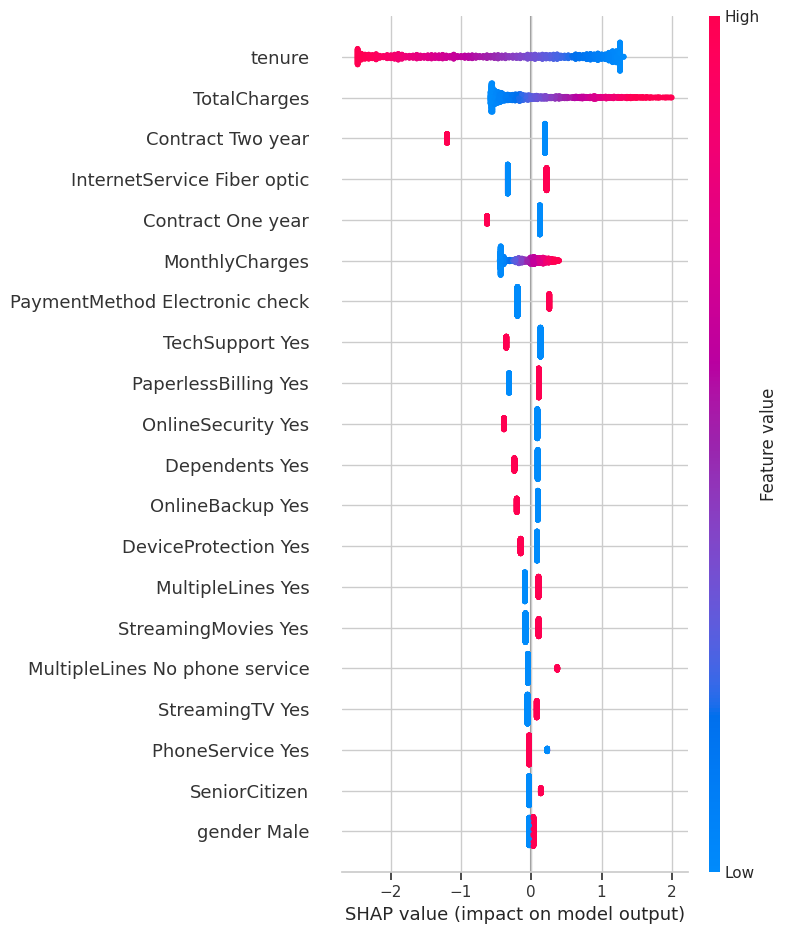

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=clean_feature_names,
    show=True
)

In [ ]:
segmentation_features = df_clean[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].copy()

print(segmentation_features.head())
print("\nShape:", segmentation_features.shape)

   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65

Shape: (7043, 3)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

segmentation_scaled = scaler.fit_transform(
    segmentation_features
)

print("Scaled data shape:", segmentation_scaled.shape)

Scaled data shape: (7043, 3)


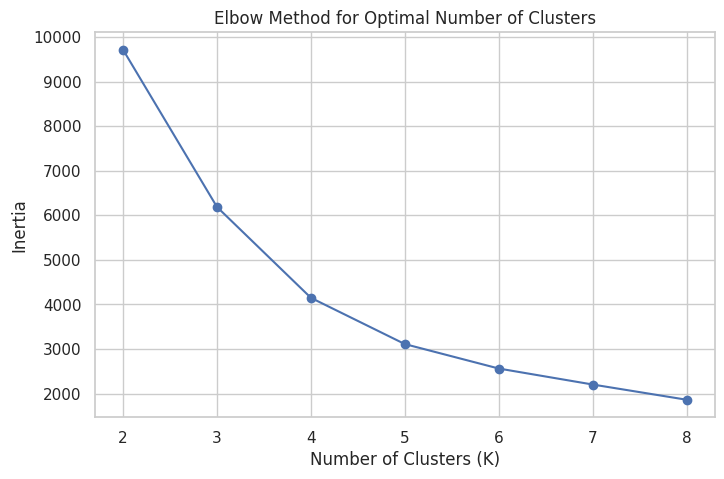

In [ ]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(segmentation_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_clean["Cluster"] = kmeans.fit_predict(segmentation_scaled)

print("Cluster distribution:")
print(df_clean["Cluster"].value_counts().sort_index())

Cluster distribution:
Cluster
0    1703
1    1904
2    2276
3    1160
Name: count, dtype: int64


In [ ]:
cluster_profile = df_clean.groupby("Cluster")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)

cluster_profile

,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,10.21,31.78,302.15
1,59.53,93.31,5548.65
2,15.42,80.78,1251.17
3,53.57,34.91,1835.62


In [ ]:
cluster_churn = df_clean.groupby("Cluster")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).round(2)

cluster_profile["ChurnRate"] = cluster_churn

cluster_profile

,tenure,MonthlyCharges,TotalCharges,ChurnRate
Cluster,,,,
0,10.21,31.78,302.15,24.66
1,59.53,93.31,5548.65,15.39
2,15.42,80.78,1251.17,48.24
3,53.57,34.91,1835.62,5.00


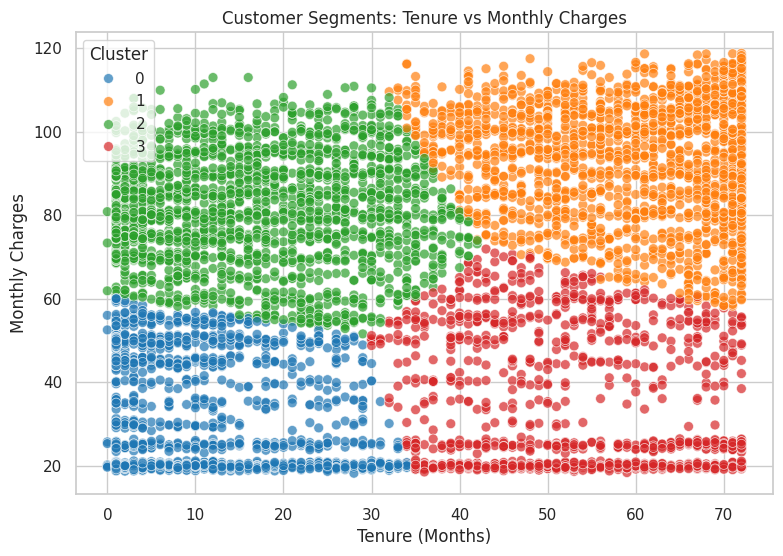

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="tenure",
    y="MonthlyCharges",
    hue="Cluster",
    palette="tab10",
    s=50,
    alpha=0.7
)

plt.title("Customer Segments: Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.legend(title="Cluster")

plt.show()

In [ ]:
segment_names = {
    0: "New Low-Spend Customers",
    1: "Long-Term High-Value Customers",
    2: "New High-Charge High-Risk Customers",
    3: "Long-Term Loyal Customers"
}

df_clean["Segment"] = df_clean["Cluster"].map(segment_names)

print(df_clean["Segment"].value_counts())

Segment
New High-Charge High-Risk Customers    2276
Long-Term High-Value Customers         1904
New Low-Spend Customers                1703
Long-Term Loyal Customers              1160
Name: count, dtype: int64


In [ ]:
segment_summary = df_clean.groupby("Segment").agg(
    Customers=("Segment", "size"),
    AvgTenure=("tenure", "mean"),
    AvgMonthlyCharges=("MonthlyCharges", "mean"),
    AvgTotalCharges=("TotalCharges", "mean"),
    ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
).round(2)

segment_summary

,Customers,AvgTenure,AvgMonthlyCharges,AvgTotalCharges,ChurnRate
Segment,,,,,
Long-Term High-Value Customers,1904,59.53,93.31,5548.65,15.39
Long-Term Loyal Customers,1160,53.57,34.91,1835.62,5.00
New High-Charge High-Risk Customers,2276,15.42,80.78,1251.17,48.24
New Low-Spend Customers,1703,10.21,31.78,302.15,24.66


In [ ]:
business_recommendations = pd.DataFrame({
    "Segment": [
        "New High-Charge High-Risk Customers",
        "Long-Term High-Value Customers",
        "Long-Term Loyal Customers",
        "New Low-Spend Customers"
    ],
    "Priority": [
        "Very High",
        "High",
        "Low",
        "Medium"
    ],
    "Recommended_Action": [
        "Proactive retention offers, onboarding support, and service issue resolution",
        "Loyalty rewards, premium support, and personalized retention benefits",
        "Referral programs, loyalty rewards, and relationship-building offers",
        "Onboarding campaigns, engagement offers, and service education"
    ]
})

business_recommendations

,Segment,Priority,Recommended_Action
0,New High-Charge High-Risk Customers,Very High,"Proactive retention offers, onboarding support..."
1,Long-Term High-Value Customers,High,"Loyalty rewards, premium support, and personal..."
2,Long-Term Loyal Customers,Low,"Referral programs, loyalty rewards, and relati..."
3,New Low-Spend Customers,Medium,"Onboarding campaigns, engagement offers, and s..."


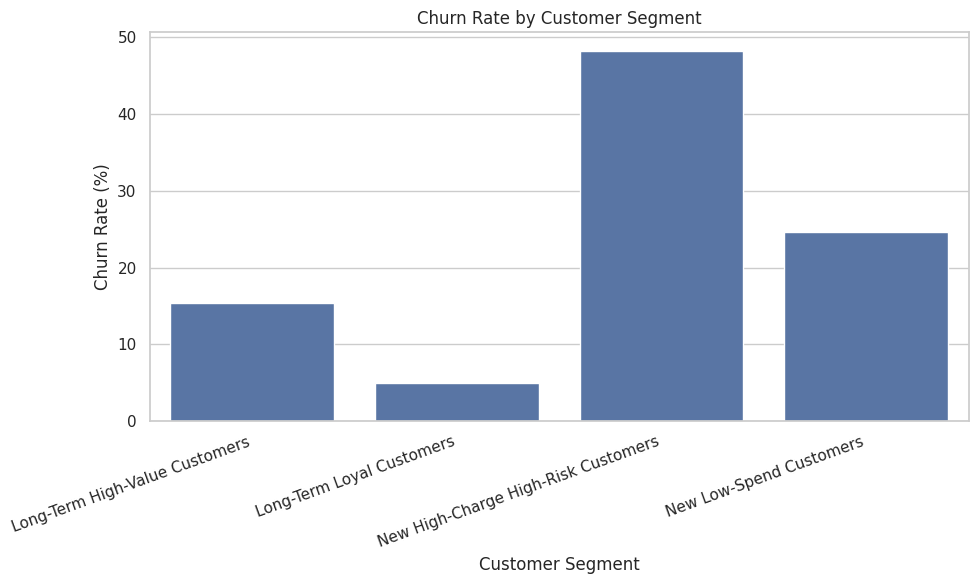

In [ ]:
segment_churn = segment_summary.reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_churn,
    x="Segment",
    y="ChurnRate"
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
final_model = logistic_smote

final_pred = y_pred_smote
final_prob = y_prob_smote

final_metrics = {
    "Accuracy": accuracy_smote,
    "Precision": precision_smote,
    "Recall": recall_smote,
    "F1-Score": f1_score(y_test, y_pred_smote),
    "ROC-AUC": roc_auc_score(y_test, y_prob_smote)
}

print("FINAL MODEL: Logistic Regression + SMOTE")
print("-----------------------------------------")

for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

FINAL MODEL: Logistic Regression + SMOTE
-----------------------------------------
Accuracy: 0.7367
Precision: 0.5026
Recall: 0.7861
F1-Score: 0.6131
ROC-AUC: 0.8398


In [ ]:
final_model = logistic_smote

final_pred = y_pred_smote
final_prob = y_prob_smote

final_metrics = {
    "Accuracy": accuracy_smote,
    "Precision": precision_smote,
    "Recall": recall_smote,
    "F1-Score": f1_score(y_test, y_pred_smote),
    "ROC-AUC": roc_auc_score(y_test, y_prob_smote)
}

print("FINAL MODEL: Logistic Regression + SMOTE")
print("-----------------------------------------")

for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

FINAL MODEL: Logistic Regression + SMOTE
-----------------------------------------
Accuracy: 0.7367
Precision: 0.5026
Recall: 0.7861
F1-Score: 0.6131
ROC-AUC: 0.8398


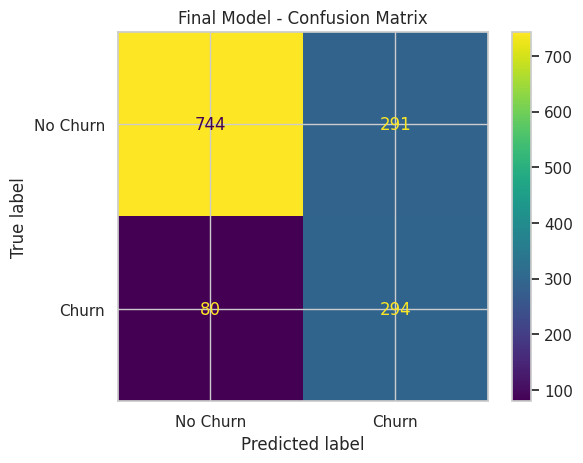

In [ ]:
cm_final = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Final Model - Confusion Matrix")
plt.show()

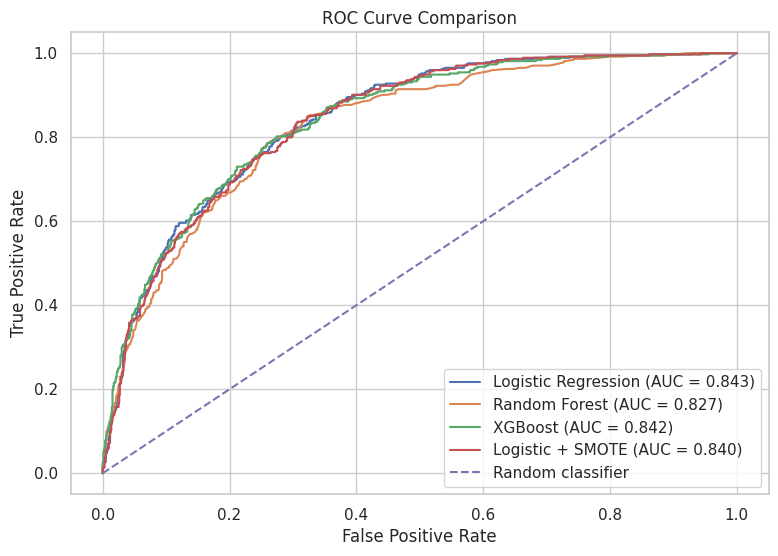

In [ ]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_xgb:.3f})"
)

plt.plot(
    fpr_smote,
    tpr_smote,
    label=f"Logistic + SMOTE (AUC = {roc_auc_smote:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        final_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
# Clone the GitHub repository
!git clone https://github.com/Chaitanyaprabhu08/explainable-customer-churn-ml.git

fatal: destination path 'explainable-customer-churn-ml' already exists and is not an empty directory.


In [ ]:

import pandas as pd

file_path = "explainable-customer-churn-ml/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 13. Conclusion

This project developed an explainable machine learning framework for telecom customer churn prediction and customer segmentation.

Several machine learning models were evaluated, including Logistic Regression, Random Forest, and XGBoost. Logistic Regression with SMOTE was selected as the churn-focused model because it achieved a recall of 78.61%, allowing the system to identify a larger proportion of actual churners. Although its overall accuracy was lower than the baseline Logistic Regression model, the higher recall is more suitable for a customer retention scenario where missing potential churners can be costly.

SHAP was used to make the model predictions explainable. The analysis showed that features such as tenure, TotalCharges, contract type, MonthlyCharges, InternetService, and payment method had important influences on churn predictions.

K-Means clustering was also used to segment customers based on tenure, MonthlyCharges, and TotalCharges. The segmentation identified four customer groups with different churn risks, helping businesses design targeted retention strategies.

Overall, the project combines churn prediction, model explainability, and customer segmentation to support data-driven customer retention decisions.

### Key Business Insights

- Customers with shorter tenure showed higher churn risk.
- Month-to-month contracts were strongly associated with higher churn.
- New customers with relatively high monthly charges formed the highest-risk segment.
- Long-term loyal customers showed the lowest churn rate.
- SHAP explanations can help understand why individual customers are classified as high-risk.
- Customer segmentation can help businesses apply different retention strategies to different customer groups.